In [ ]:
!pip install split-folders


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Copying files: 600 files [00:16, 37.13 files/s]

Dataset selesai di-split!
Found 480 images belonging to 12 classes.
Found 60 images belonging to 12 classes.
Found 60 images belonging to 12 classes.


Classes: ['abyssinian_nobg', 'bengal_nobg', 'birman_nobg', 'bombay_nobg', 'british_shorthair_nobg', 'egyptian_nobg', 'mainecoon_nobg', 'persian_nobg', 'ragdoll_nobg', 'russian_nobg', 'siamese_nobg', 'sphynx_nobg']


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.2442 - loss: 2.2899 - val_accuracy: 0.4000 - val_loss: 1.6883
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.8985 - loss: 0.6118 - val_accuracy: 0.6667 - val_loss: 1.1264
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.9462 - loss: 0.2871 - val_accuracy: 0.6667 - val_loss: 0.9501
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.9619 - loss: 0.1762 - val_accuracy: 0.8000 - val_loss: 0.6590
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.9734 - loss: 0.1198 - val_accuracy: 0.8333 - val_loss: 0.6577
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.9716 - loss: 0.1162 - val_accuracy: 0.8500 - val_loss: 0.4954
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.9815 - loss: 0.0602 - val_accuracy: 0.8667 - val_loss: 0.5243
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.9959 - loss: 0.0409 - val_accuracy: 0.9167 - v

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

Evaluasi Validation
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


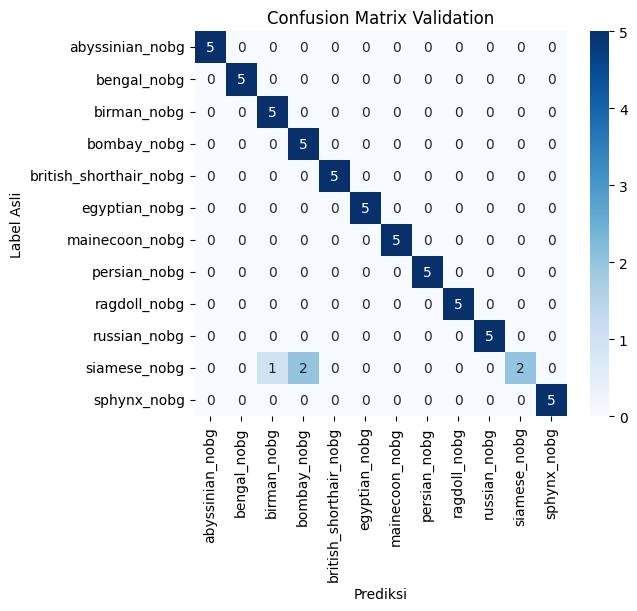


Classification Report Validation :
                        precision    recall  f1-score   support

       abyssinian_nobg       1.00      1.00      1.00         5
           bengal_nobg       1.00      1.00      1.00         5
           birman_nobg       0.83      1.00      0.91         5
           bombay_nobg       0.71      1.00      0.83         5
british_shorthair_nobg       1.00      1.00      1.00         5
         egyptian_nobg       1.00      1.00      1.00         5
        mainecoon_nobg       1.00      1.00      1.00         5
          persian_nobg       1.00      1.00      1.00         5
          ragdoll_nobg       1.00      1.00      1.00         5
          russian_nobg       1.00      1.00      1.00         5
          siamese_nobg       1.00      0.40      0.57         5
           sphynx_nobg       1.00      1.00      1.00         5

              accuracy                           0.95        60
             macro avg       0.96      0.95      0.94        60
  

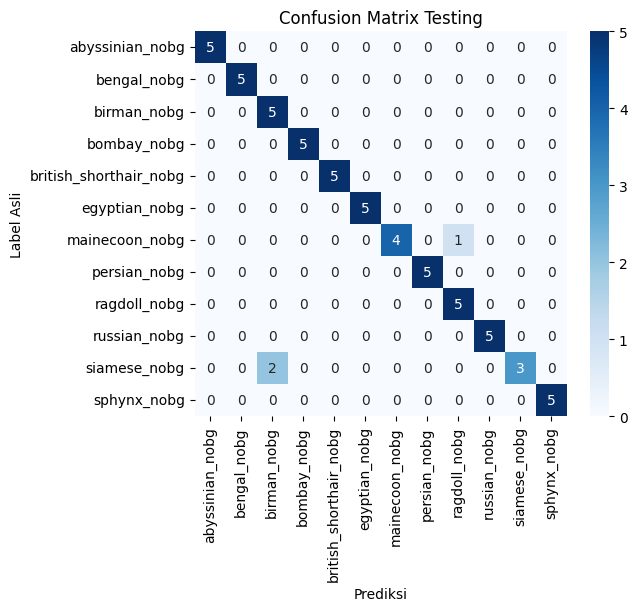


Classification Report Testing :
                        precision    recall  f1-score   support

       abyssinian_nobg       1.00      1.00      1.00         5
           bengal_nobg       1.00      1.00      1.00         5
           birman_nobg       0.71      1.00      0.83         5
           bombay_nobg       1.00      1.00      1.00         5
british_shorthair_nobg       1.00      1.00      1.00         5
         egyptian_nobg       1.00      1.00      1.00         5
        mainecoon_nobg       1.00      0.80      0.89         5
          persian_nobg       1.00      1.00      1.00         5
          ragdoll_nobg       0.83      1.00      0.91         5
          russian_nobg       1.00      1.00      1.00         5
          siamese_nobg       1.00      0.60      0.75         5
           sphynx_nobg       1.00      1.00      1.00         5

              accuracy                           0.95        60
             macro avg       0.96      0.95      0.95        60
     

In [ ]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

input_folder = "/content/drive/MyDrive/Colab Notebooks/dataset_kucing"
output_folder = "/content/drive/MyDrive/Colab Notebooks/dataset_kucing_split"

!rm -rf "/content/drive/MyDrive/Colab Notebooks/dataset_kucing_split"

import splitfolders

# Split data
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import os


# Augmentasi data
train_dir = f"{output_folder}/train"
val_dir   = f"{output_folder}/val"
test_dir  = f"{output_folder}/test"

train_datagen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1/255.0)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)


# Define model
base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = GlobalAveragePooling2D()(base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(classes), activation="softmax")(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Latih model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[early_stop]
)


# Uji model
print("\nTESTING")
test_gen.reset()

y_pred_prob_test = model.predict(test_gen)
y_pred_test = np.argmax(y_pred_prob_test, axis=1)
y_true_test = test_gen.classes

# Evaluasi data validasi
print("\nEvaluasi Validation")

val_gen.reset()
y_pred_val = np.argmax(model.predict(val_gen), axis=1)
y_true_val = val_gen.classes

cm_val = confusion_matrix(y_true_val, y_pred_val)

plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Validation")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.show()

print("\nClassification Report Validation :")
print(classification_report(y_true_val, y_pred_val, target_names=classes))

# Evaluasi data uji
print("\nEVALUASI TESTING")

cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Testing")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.show()

print("\nClassification Report Testing :")
print(classification_report(y_true_test, y_pred_test, target_names=classes))

test_loss, test_acc = model.evaluate(test_gen)
print(f"\nAkurasi Testing : {test_acc:.4f}")


In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/model_kucing3.keras")

Mounted at /content/drive
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


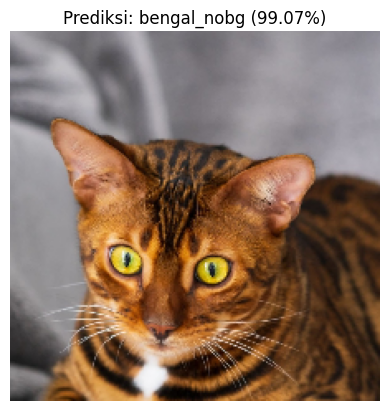

Hasil prediksi: bengal_nobg (99.07%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


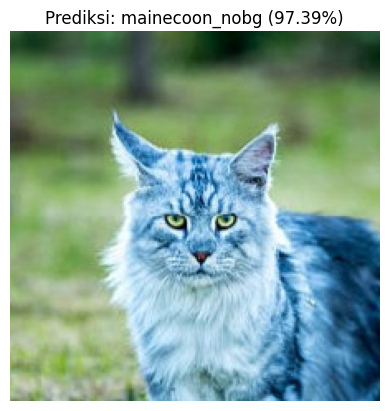

Hasil prediksi: mainecoon_nobg (97.39%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


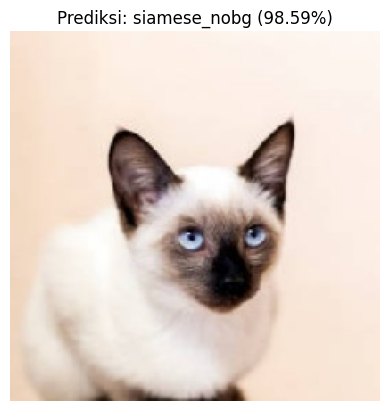

Hasil prediksi: siamese_nobg (98.59%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


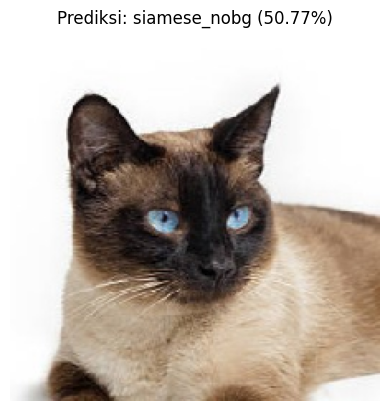

Hasil prediksi: siamese_nobg (50.77%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


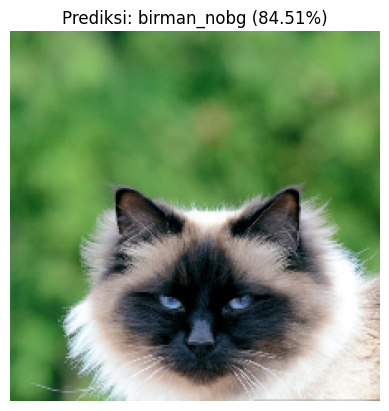

Hasil prediksi: birman_nobg (84.51%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


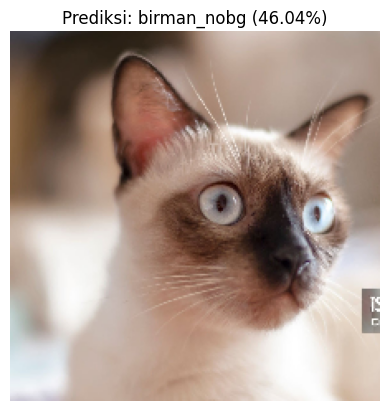

Hasil prediksi: birman_nobg (46.04%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


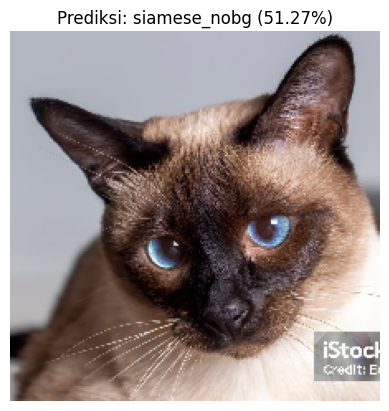

Hasil prediksi: siamese_nobg (51.27%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


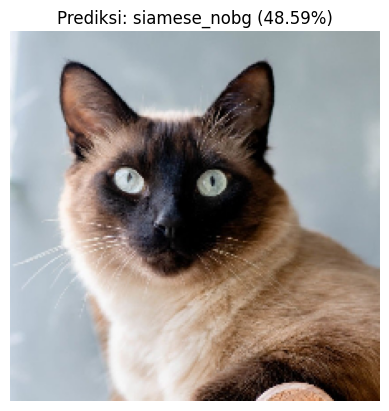

Hasil prediksi: siamese_nobg (48.59%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


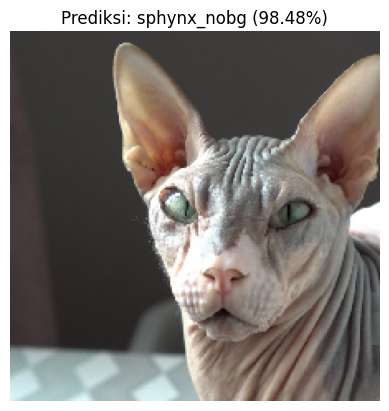

Hasil prediksi: sphynx_nobg (98.48%)



In [1]:
from google.colab import drive
drive.mount('/content/drive')
model_path = "/content/drive/MyDrive/Colab Notebooks/model_kucing3.keras"
new_image_paths = [
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/bengal.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/mainecoon.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/siamese1.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/siamese2.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/birman.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/siamese3.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/siamese4.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/siamese5.jpg",
    "/content/drive/MyDrive/Colab Notebooks/gambar_baru/sphynx.jpg"
]

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# load model
model = load_model(model_path)
classes = ['abyssinian_nobg', 'bengal_nobg', 'birman_nobg', 'bombay_nobg',
           'british_shorthair_nobg', 'egyptian_nobg', 'mainecoon_nobg',
           'persian_nobg', 'ragdoll_nobg', 'russian_nobg', 'siamese_nobg', 'sphynx_nobg']

# prediksi gambar
def predict_image(img_path):
    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_id = np.argmax(pred)
    confidence = pred[0][class_id]*100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {classes[class_id]} ({confidence:.2f}%)")
    plt.show()

    return classes[class_id], confidence

# uji
for img_path in new_image_paths:
    pred_class, conf = predict_image(img_path)
    print(f"Hasil prediksi: {pred_class} ({conf:.2f}%)\n")
